<a href="https://colab.research.google.com/github/diegogr98/Diego-Gutierrez-Astronomy/blob/main/gravitational_ray_tracing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autor:** Diego Gutierrez Rodriguez


**Objetivo:** Sintetización Monte Carlo de la silueta de un agujero negro con Ray Tracing


##*Parte 1:distribución de la posición inicial de los rayos en el plano yz.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
from scipy.integrate import odeint

In [ ]:
#Constantes del problema
A=10

#Ecuaciones
def refindex(x, y):
    eps = 1e-6  # Corrección para evitar división por cero
    rp0 = np.sqrt(x**2 + y**2)

    n = 1 / (1 - A / (rp0 + eps))  # Índice de refracción efectivo
    fac = np.abs(1 - (9/8) * (A / rp0)**2)  # Factor correctivo

    # Gradientes de n con respecto a x e y
    nx = -fac * n**2 * A * x / (rp0 + eps)**3
    ny = -fac * n**2 * A * y / (rp0 + eps)**3

    return [n, nx, ny]

def flow_deriv(state, t):
    x, y, vx, vy = state
    n, nx, ny = refindex(x, y)

    # Definimos el sistema de EDOs
    dxdt = vx / n
    dydt = vy / n
    dvxdt = nx
    dvydt = ny

    return [dxdt, dydt, dvxdt, dvydt]

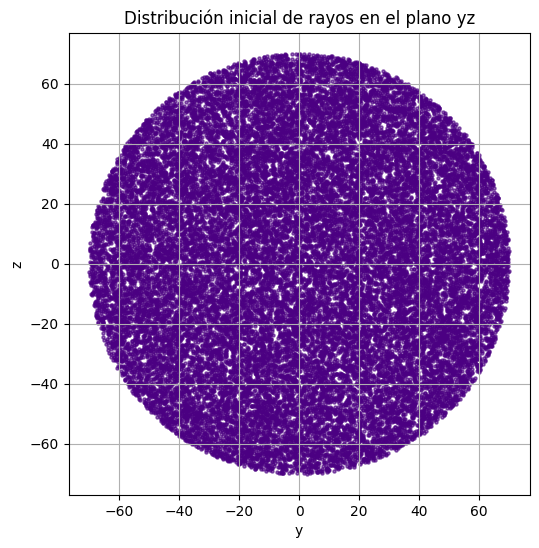

In [ ]:
# Generando puntos aleatorios
N = 30000
R = 70
# Puntos aleatorios en coordenadas polares
r = R * np.sqrt(np.random.rand(N))
theta = 2 * np.pi * np.random.rand(N)

# Convertir a coordenadas cartesianas en el plano yz
y0 = r * np.cos(theta)
z0 = r * np.sin(theta)

# Coordenadas cilíndricas
r0 = np.sqrt(y0**2 + z0**2)
theta0 = np.arctan2(z0, y0)  # Ángulo en radianes entre -π y π

# Visualización
plt.figure(figsize=(6,6))
plt.scatter(y0, z0, s=5, alpha=0.6, color='indigo')
plt.gca().set_aspect('equal')
plt.title('Distribución inicial de rayos en el plano yz')
plt.xlabel('y')
plt.ylabel('z')
plt.grid(True)
plt.show()

##*Parte 2: Integración de Rayos en el Plano x,y*

<ipython-input-4-36eee0406847>:26: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(flow_deriv, estado_inicial, tspan)


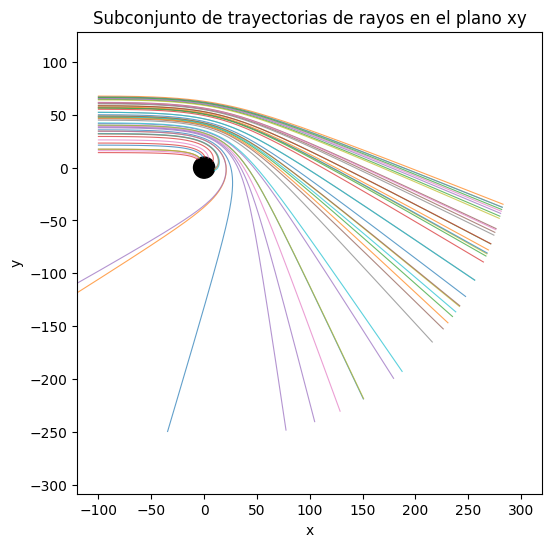

In [ ]:
# Ignorar advertencias de integración y cálculos numéricos
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Constantes
xstart = -100
tspan = np.arange(0, 401, 1)  # ∆t = 1
xlim = ylim = 300

# Trayectorias truncadas
trayectorias_t = []

# Elegimos rayos para graficar sin repetirlos
subcon_rayos = np.random.choice(N, size=50, replace=False)

plt.figure(figsize=(6, 6))

for i in range(N):
    ystart = r0[i]

    # Velocidad inicial vx = n(x, y), vy = 0
    n_val, _, _ = refindex(xstart, ystart)
    estado_inicial = [xstart, ystart, n_val, 0.0]

    # Integrar trayectoria
    sol = odeint(flow_deriv, estado_inicial, tspan)
    x = sol[:, 0]
    y = sol[:, 1]
    r = np.sqrt(x**2 + y**2)

    # Verificar dónde truncar
    dentro_horizonte = r < A
    fuera_rango = (np.abs(x) > xlim) | (np.abs(y) > ylim)
    truncar_en = np.where(dentro_horizonte | fuera_rango)[0]

    if len(truncar_en) > 0:
        corte = truncar_en[0]
        x = x[:corte]
        y = y[:corte]

    trayectorias_t.append((x, y))

    # Graficar sólo si está en los seleccionados
    if i in subcon_rayos:
        plt.plot(x, y, lw=0.8, alpha=0.7)

# Círculo del agujero negro
agujero = plt.Circle((0, 0), radius=A, color='black')
plt.gca().add_patch(agujero)
plt.axis('equal')
plt.xlim(-120, 320)
plt.ylim(-250, 70)
plt.title('Subconjunto de trayectorias de rayos en el plano xy')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

##*Parte 3: Construcción de un Disco Inclinado*

In [ ]:
# Parámetros del disco
Nd = 5000
R_in = 15
R_out = 50

# Disco en coordenadas polares
theta_d = 2 * np.pi * np.random.rand(Nd)
r_d = np.sqrt(R_in**2 + (R_out**2 - R_in**2) * np.random.rand(Nd))

# Disco en el plano xy ( para rotar en y)
x_d = r_d * np.cos(theta_d)
y_d = r_d * np.sin(theta_d)
z_d = np.zeros_like(x_d)  # plano xy → z = 0

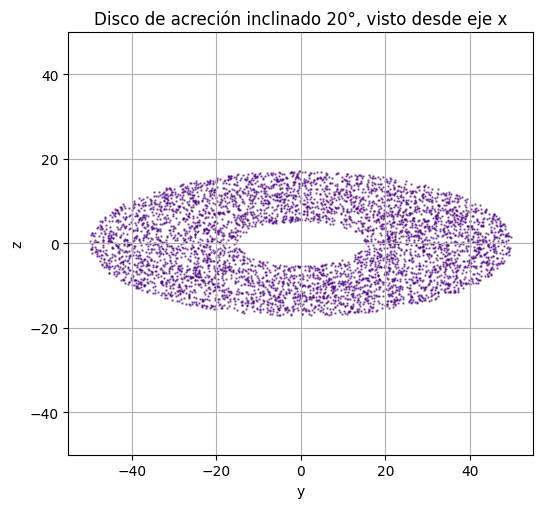

In [ ]:
from scipy.spatial.transform import Rotation as R
# Agrupar en matriz (N, 3)
disco = np.vstack((x_d, y_d, z_d)).T

# Rotar el disco 20° alrededor del eje y
rot = R.from_euler('y', 20, degrees=True)
disco_rotado = rot.apply(disco)

# Graficando la proyección de x, plano (y, z)
y_rot = disco_rotado[:,1]
z_rot = disco_rotado[:,2]

d_ave = np.sqrt(np.pi * R_out**2 / Nd)

# Graficando el disco inclinado
plt.figure(figsize=(6,6))
plt.scatter(y_rot, z_rot, s=0.5, color='indigo', alpha=0.6)
plt.gca().set_aspect('equal')
plt.title('Disco de acreción inclinado 20°, visto desde eje x')
plt.xlabel('y')
plt.ylabel('z')
plt.xlim(-55, 55)
plt.ylim(-50, 50)
plt.grid(True)
plt.show()

##*Parte 4: Intersecciones Rayo-Disco en 3D y Síntesis de la Imagen*

In [ ]:
#definiedno la matriz de rotación
def rotacion_x(theta):
    c = np.cos(theta)
    s = np.sin(theta)

    R = np.array([
        [1, 0,  0],
        [0, c, -s],
        [0, s,  c]
    ])

    return R
# Definiendo una función que rota las trayectorias
def aplicar_rotacion_x(x, y, theta):
    z = np.zeros_like(x)
    puntos = np.vstack((x, y, z)).T  # (n, 3)

    R = rotacion_x(theta)
    puntos_rotados = puntos @ R.T  # Multiplicación fila × matriz

    return puntos_rotados  # shape (n, 3)

In [ ]:
trayectorias_rotadas = []

for (x, y), theta in zip(trayectorias_t, theta0):
    # Convertir la trayectoria (x,y) en puntos 3D con z=0
    puntos_rotados = aplicar_rotacion_x(x, y, theta)  # shape (len(x), 3)

    # Extraer las nuevas coordenadas
    x_rot = puntos_rotados[:, 0]
    y_rot = puntos_rotados[:, 1]
    z_rot = puntos_rotados[:, 2]

    # Guardar la trayectoria rotada
    trayectorias_rotadas.append((x_rot, y_rot, z_rot))

In [ ]:
def verificar_interseccion(rayo_3d, disco_rotado, d_ave):

    # Expandimos dimensiones para broadcasting
    rayo_3d_expanded = rayo_3d[:, np.newaxis, :]
    disco_rotado_expanded = disco_rotado[np.newaxis, :, :]

    # Calculamos distancias entre todos los puntos del rayo y los del disco
    diff = rayo_3d_expanded - disco_rotado_expanded
    distancias = np.linalg.norm(diff, axis=2)

    # Encontramos qué puntos intersectan
    intersecta = np.any(distancias < d_ave, axis=1)
    hay_interseccion = np.any(intersecta)

    # Calculamos distancia al origen de los puntos de intersección
    distancia_interseccion_origen = None
    if hay_interseccion:
        # Tomamos los puntos del rayo que intersectan el disco
        puntos_intersectan = rayo_3d[intersecta]
        distancias_al_origen = np.linalg.norm(puntos_intersectan, axis=1)
        distancia_interseccion_origen = np.min(distancias_al_origen)

    return hay_interseccion, distancia_interseccion_origen

rayos_intersectados = []
distancias_minimas = []
indices_intersectados = []


#hallando si intersecta el disco
for i, rayo_3d in enumerate(trayectorias_rotadas):
    x_r, y_r, z_r = rayo_3d
    trayectoria_array = np.stack((x_r, y_r, z_r), axis=1)

    intersecta, distancia_min = verificar_interseccion(trayectoria_array,
                                                       disco_rotado,
                                                       d_ave)

    #creamos una lista de booleanos
    if intersecta:
        rayos_intersectados.append(True)
        distancias_minimas.append(distancia_min)
        indices_intersectados.append(i)
    else:
        rayos_intersectados.append(False)


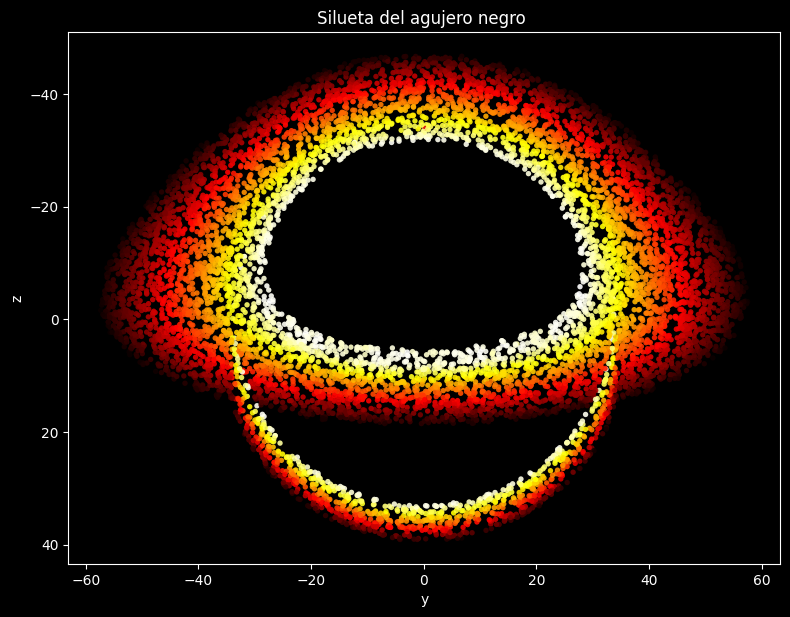

In [ ]:
# Normalizamos los colores por la distancia mínima
norm = plt.Normalize(np.min(distancias_minimas), np.max(distancias_minimas))
colores = plt.cm.hot_r(norm(distancias_minimas))

# Extraemos los puntos iniciales correspondientes a los índices
y0_i = [y0[i] for i in indices_intersectados]
z0_i = [z0[i] for i in indices_intersectados]

# Crear figura
plt.figure(figsize=(8, 8))
plt.style.use('dark_background')

plt.scatter(y0_i, z0_i, s=15, c=colores,
            cmap='hot_r', alpha=0.9, edgecolors='none')

plt.gca().set_aspect('equal')
plt.title('Silueta del agujero negro ', color='white')
plt.xlabel('y', color='white')
plt.ylabel('z', color='white')
plt.tick_params(axis='both', colors='white')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()